## Load notebook

### Python modules

In [1]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('./XPCSlibrary/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Load e4m masks

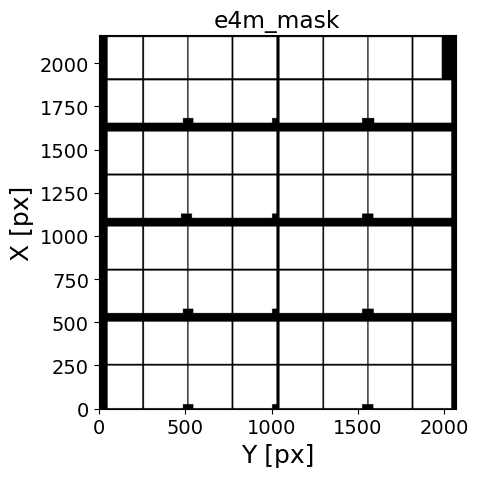

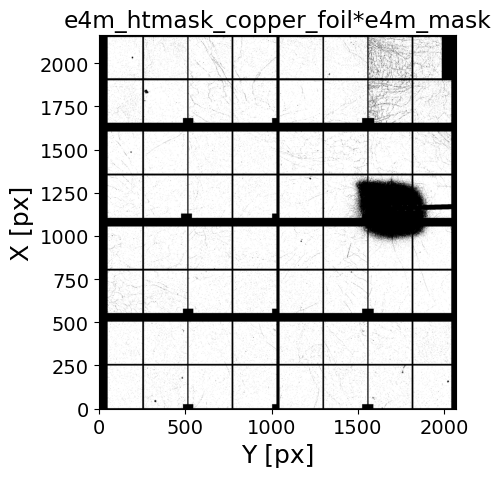

In [2]:
### e4m MASKS
e4m_htmask_copper_foil = np.load(MASKS_folder+'e4m_htmask_copper_foil_30um_1_1'+'.npy')
e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.title('e4m_mask')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 5))
plt.imshow((e4m_htmask_copper_foil*e4m_mask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.title('e4m_htmask_copper_foil*e4m_mask')
plt.tight_layout()

## XPCS scan 4 analyisis

In [3]:
#######################################
sample_name = 'GeO2_7_30C'
Ndataset = 3
Nscan = 3
#######################################

In [4]:
#######################################
Nfi, Nff = 1000, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=10)

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 33.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00014.h5 (15/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00024.h5 (25/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00020.h5 (21/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00030.h5 (31/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006

## XPCS scan 4 analyisis

In [5]:
#######################################
sample_name_bkg = 'GeO2_6q_delcoup_1'
Ndataset_bkg = 3
Nscan_bkg = 3
#######################################

In [6]:
#######################################
Nfi, Nff = None, None
#######################################

scan_bkg = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei_bkg = scan_bkg['monoe']
itime_bkg = scan_bkg['fast_timer_period'][0]
theta_bkg = scan_bkg['delcoup']
Q_bkg = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan_bkg['command'])
print('Ei =', Ei_bkg)
print('itime =', itime_bkg)
print('theta =', theta_bkg)
print('Q =', Q_bkg)
print('T = {:.2f} min'.format(len(scan_bkg['fast_timer_period'])*itime_bkg/60))   
print('#############################\n')

e4m_data_bkg = ID10.load_sparse_e4m(RAW_folder, sample_name_bkg, Ndataset_bkg, Nscan_bkg, Nfi, Nff,  n_jobs=50)
e4m_data_bkg = COSMIC.fast_gamma_filter(e4m_data_bkg, Imaxth_high=10)

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 33.01 min
#############################

Loading sparse array ...


FileNotFoundError: [Errno 2] No such file or directory: '../RAW_DATA/GeO2_6q_delcoup_1/GeO2_6q_delcoup_1_0003/scan0003/'

In [ ]:
####################
Lbin = 1
Nstep = 10
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

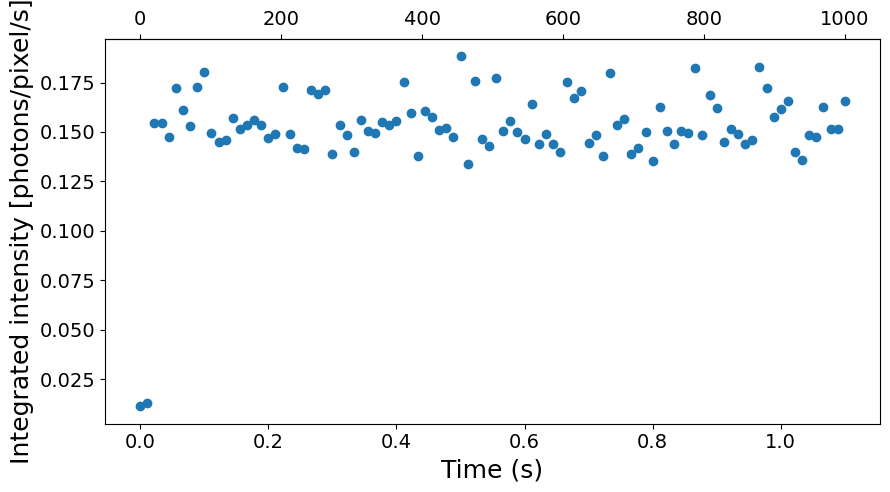

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

## Beamstop mask

In [ ]:
#######################################
Nfi, Nff = 0, 1000
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)
Done! (elapsed time = 0.01 s)
Concatenating vectors ...
Done! (elapsed time = 0.0 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_7_30C/GeO2_7_30C_0003/scan0003/
	 | Shape:       (1000, 4471016)
	 | Sparsity:     1.5e-04
	 | Memory usage (scipy.csr_array): 0.007 GB (np.array usage: 16.656 GB)


################################################################################
Maximum count in the whole run -> 242.0
# of pixels above Ith_high treshold ->  610960 pixels (of 4471016 => 13.66 %)
################################################################################



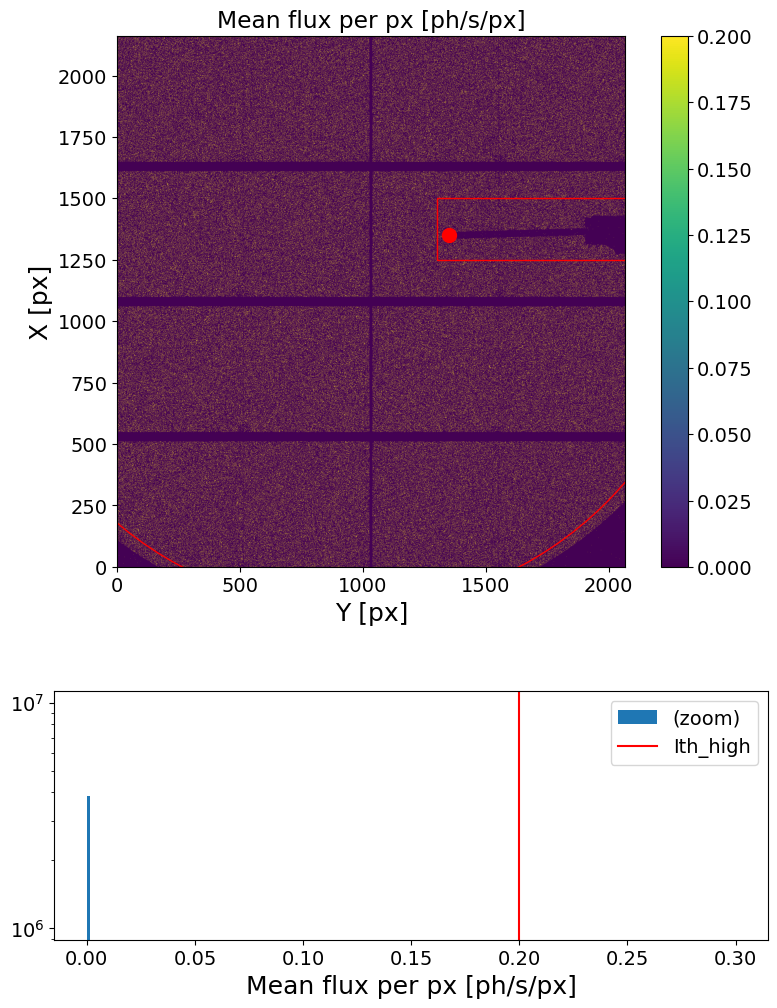

In [ ]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.2, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



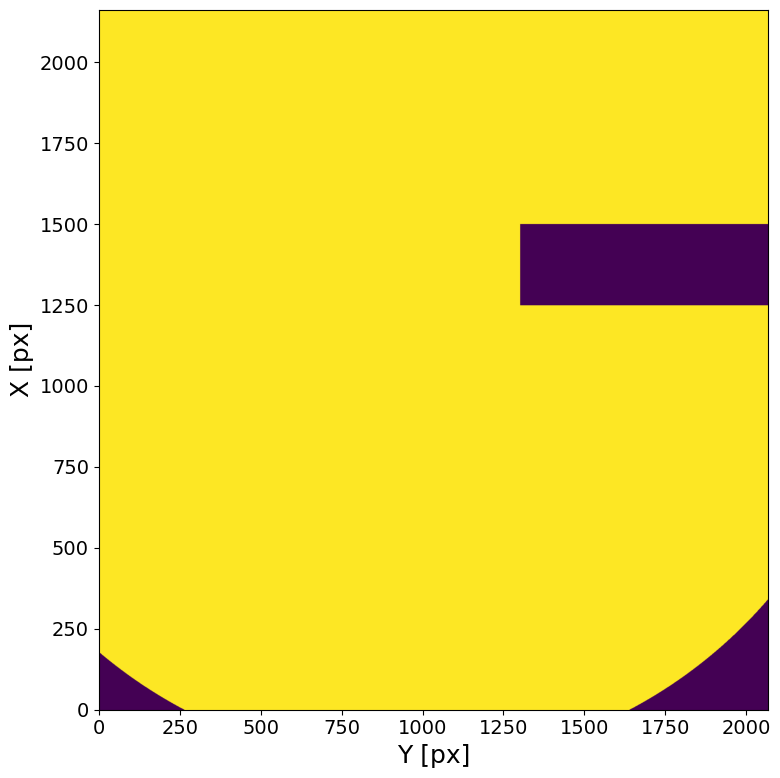

In [ ]:
bs_mask = XPCS.gen_mask(mask_geom=geom)

## XPCS scan X-Y analysis

In [ ]:
####################
Lbin = 10
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

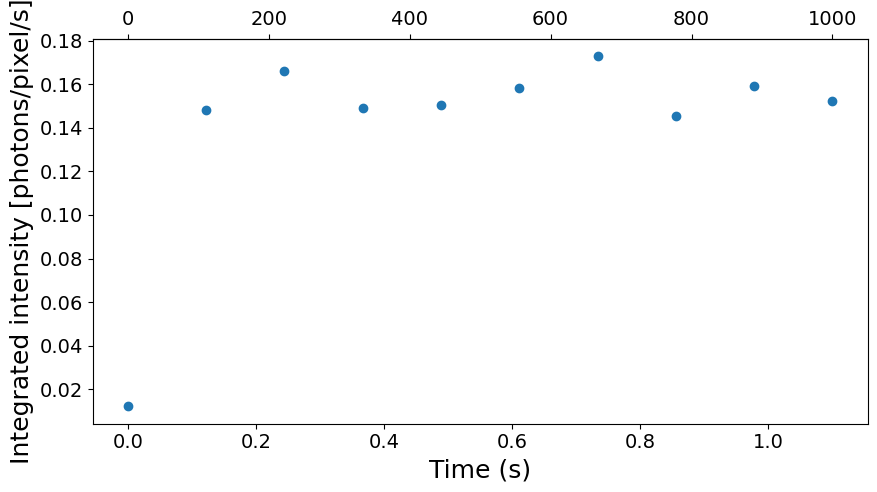

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

## Generation of a flat field mask!

### Mask generation

In [30]:
##################
Ith_low=.20
Ith_high=.25
##################

#################################################
Masked area =  0.0 %
#################################################



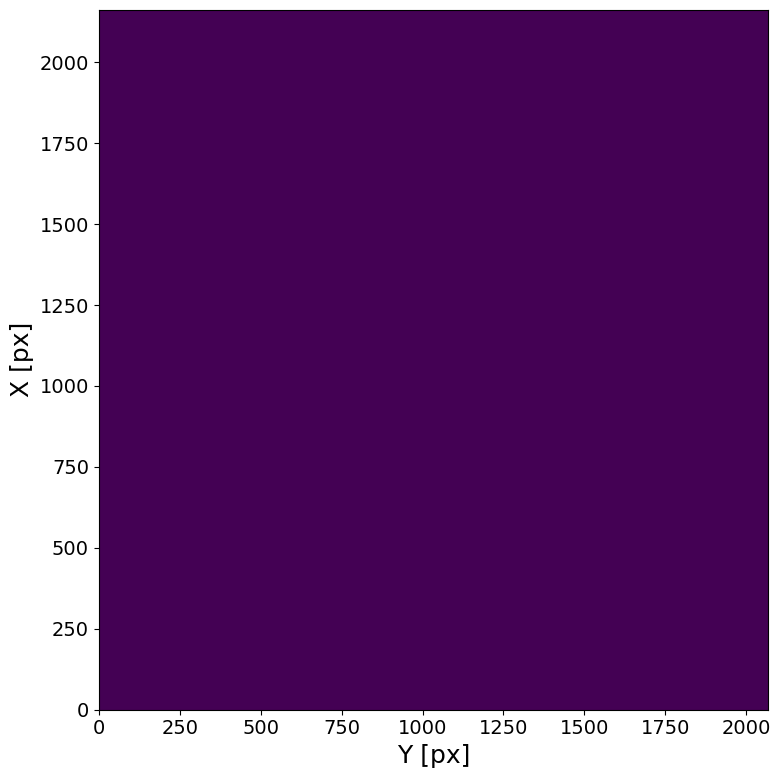

In [31]:
e4m_htmask = XPCS.gen_mask(e4m_data=e4m_data, itime=itime, mask=e4m_mask*bs_mask, Ith_high=Ith_high, Ith_low=Ith_low, Nfi=None, Nff=None, hist_plots=False)
np.save(MASKS_folder  + f'e4m_htmask-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}.npy', e4m_htmask)

### Flux profile with mask=e4m_mask*bs_mask

In [6]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=Ith_low, Ith_high=Ith_high, Nfi=0, Nff=None, mask=e4m_mask*bs_mask)

NameError: name 'e4m_data' is not defined

### Flux profile with mask = e4m_mask * bs_mask * e4m_htmask_copper_foil

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  250889 pixels (of 4471016 => 7.54 %)
# of pixels below Ith_low treshold ->  124978 pixels (of 4471016 => 3.76 %)
################################################################################



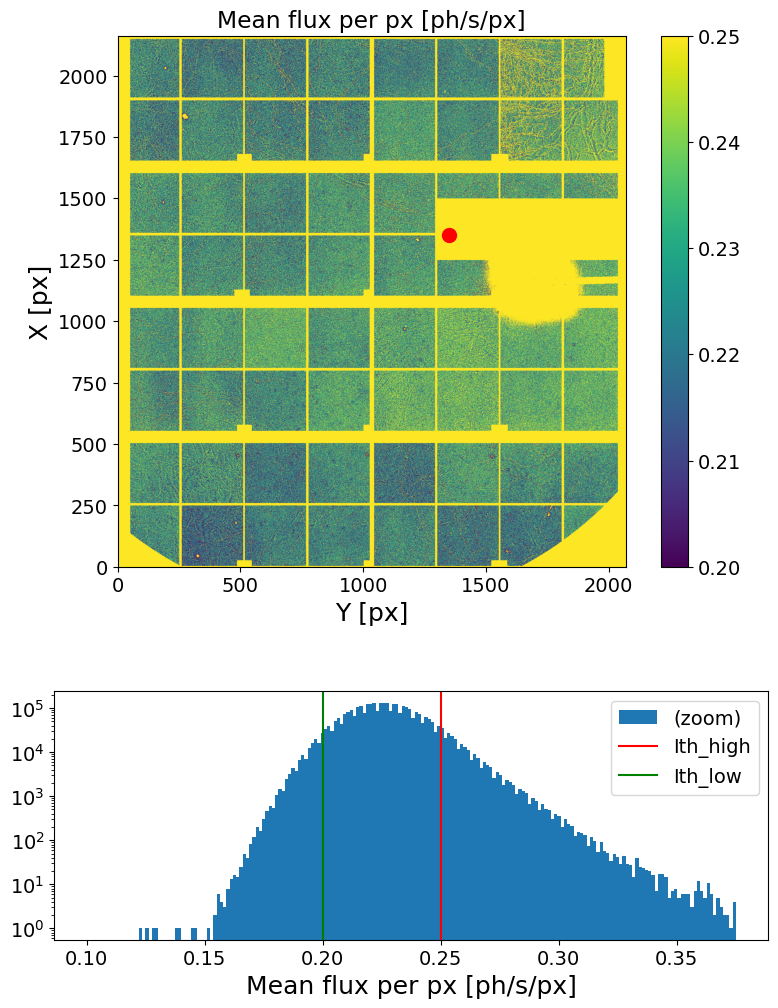

In [ ]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=Ith_low, Ith_high=Ith_high, Nfi=0, Nff=None, mask=e4m_mask*bs_mask*e4m_htmask_copper_foil)


# A better look to multiple event statistic

In [43]:
# gamma function ...
from scipy.special import gamma
gamma(2)

np.float64(1.0)

In [33]:
k = {}
k[1] = e4m_data == 1
k[2] = e4m_data == 2
k[3] = e4m_data == 3
k[4] = e4m_data == 4

k_p = {}

k_p[1] = k[1].sum(axis=0)
k_p[2] = k[2].sum(axis=0)
k_p[3] = k[3].sum(axis=0)
k_p[4] = k[4].sum(axis=0)

In [34]:
import math
P_dist = lambda k,mu: (mu**k * np.exp(-mu)) / math.factorial(k)
mu = .23e-3

## k distributions by pixel

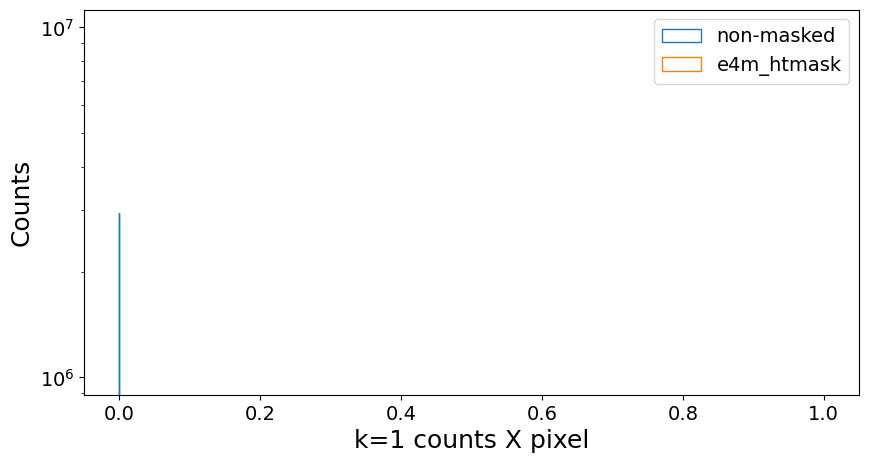

In [35]:
plt.figure(figsize=(10,5))
plt.hist(k_p[1][e4m_mask*bs_mask]/e4m_data.shape[0],        bins=200, histtype='step', label='non-masked', range=(0,0.0006))
plt.hist(k_p[1][e4m_htmask]/e4m_data.shape[0],                   bins=200, histtype='step', label='e4m_htmask')

plt.xlabel('k=1 counts X pixel')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

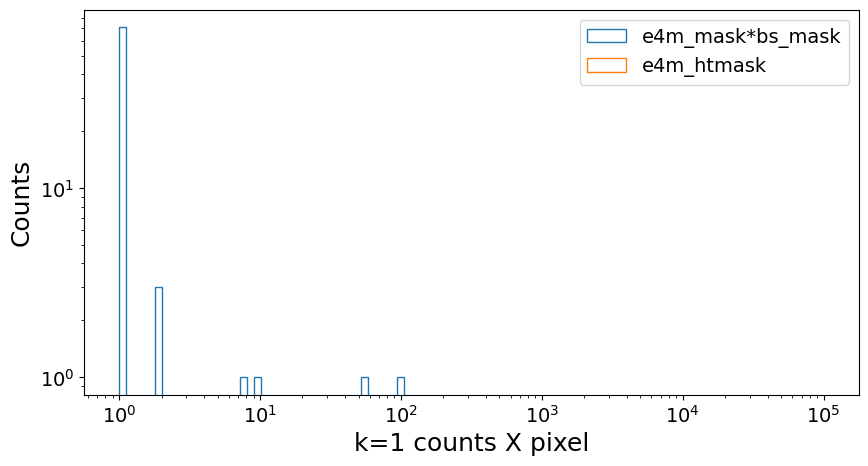

In [36]:
plt.figure(figsize=(10,5))

bins = np.logspace(np.log10(1), np.log10(1e5), 100)
#bins=None

plt.hist(k_p[2][e4m_mask*bs_mask], bins=bins, histtype='step', label='e4m_mask*bs_mask')
plt.hist(k_p[2][e4m_htmask],            bins=bins, histtype='step', label='e4m_htmask')

plt.xlabel('k=1 counts X pixel')
plt.ylabel('Counts')
plt.yscale('log')
plt.xscale('log')
plt.legend()

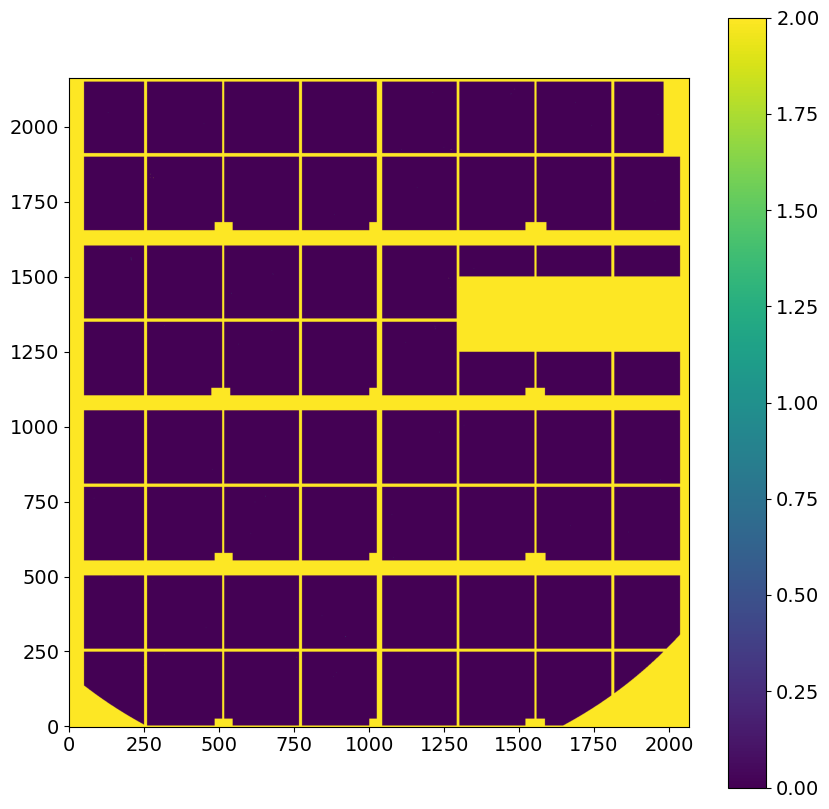

In [37]:
plt.figure(figsize=(10,10))
plt.imshow(k_p[2].reshape(Nx,Ny) + (~(e4m_mask*bs_mask)).reshape(Nx,Ny)*100, cmap='viridis', origin='lower', vmax=2)
plt.colorbar()

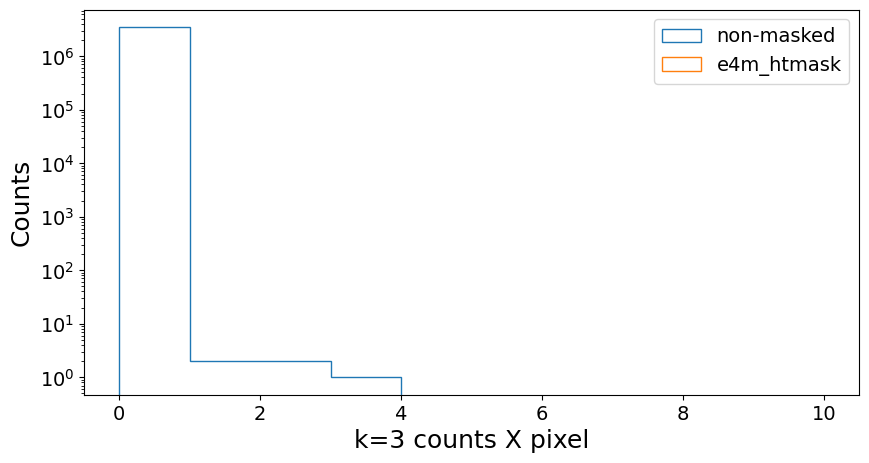

In [38]:
plt.figure(figsize=(10,5))
plt.hist(k_p[3][e4m_mask*bs_mask],        bins=10, histtype='step', label='non-masked', range=(0,10))
plt.hist(k_p[3][e4m_htmask], bins=10, histtype='step', label='e4m_htmask')

plt.xlabel('k=3 counts X pixel')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

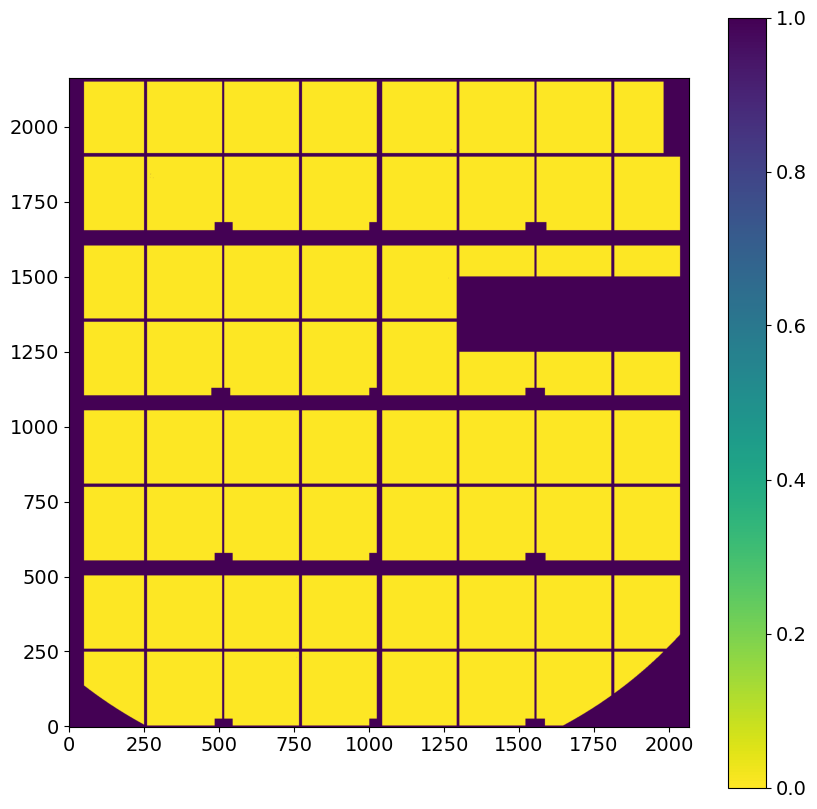

In [39]:
plt.figure(figsize=(10,10))
plt.imshow(k_p[3].reshape(Nx,Ny)+ (~(e4m_mask*bs_mask)).reshape(Nx,Ny)*100, cmap='viridis_r', origin='lower', vmax=1)
plt.colorbar()

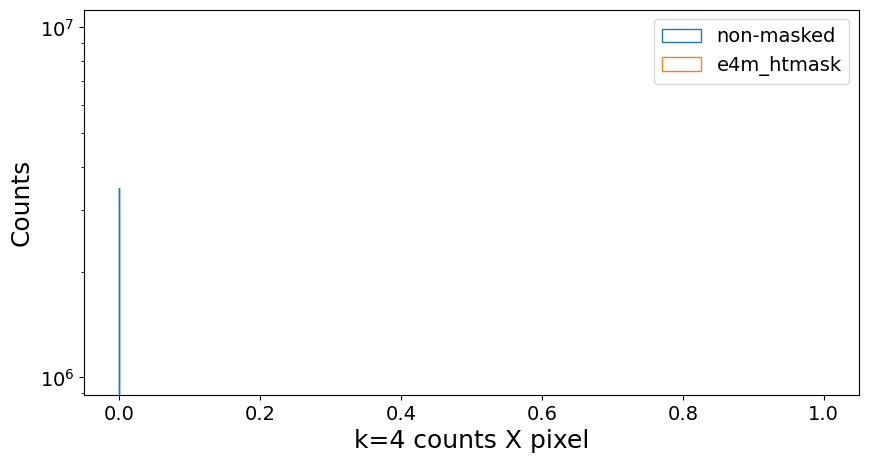

In [40]:
plt.figure(figsize=(10,5))
plt.hist(k_p[4][e4m_mask*bs_mask],        bins=100, histtype='step', label='non-masked', range=(0,0.000001))
plt.hist(k_p[4][e4m_htmask], bins=100, histtype='step', label='e4m_htmask')

plt.xlabel('k=4 counts X pixel')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

## k mask generation

In [18]:
#################
w = 7
e4m_kmask = (k_p[2]<4)*(k_p[3]==0)*(k_p[4]==0) * (k_p[1]/e4m_data.shape[0]>.00015) * (k_p[1]/e4m_data.shape[0]<.0006)
#################

# enlarge the dominium of the mask
from scipy.ndimage import binary_dilation
e4m_kmask = ~binary_dilation(~e4m_kmask.reshape(Nx, Ny), structure=np.ones((w,w)), iterations=1)
e4m_kmask = e4m_kmask.flatten()

plt.figure(figsize=(10,10))
plt.imshow(e4m_kmask.reshape(Nx,Ny), cmap='viridis', origin='lower')

NameError: name 'k_p' is not defined

## k=2 are dominated by "background" noise

In [19]:
mask = e4m_kmask*e4m_mask*bs_mask
idxs = np.where(((k[2][:,mask]).sum(axis=1) > 3))[0]
print(len(idxs)/k[2].shape[0])

NameError: name 'e4m_kmask' is not defined

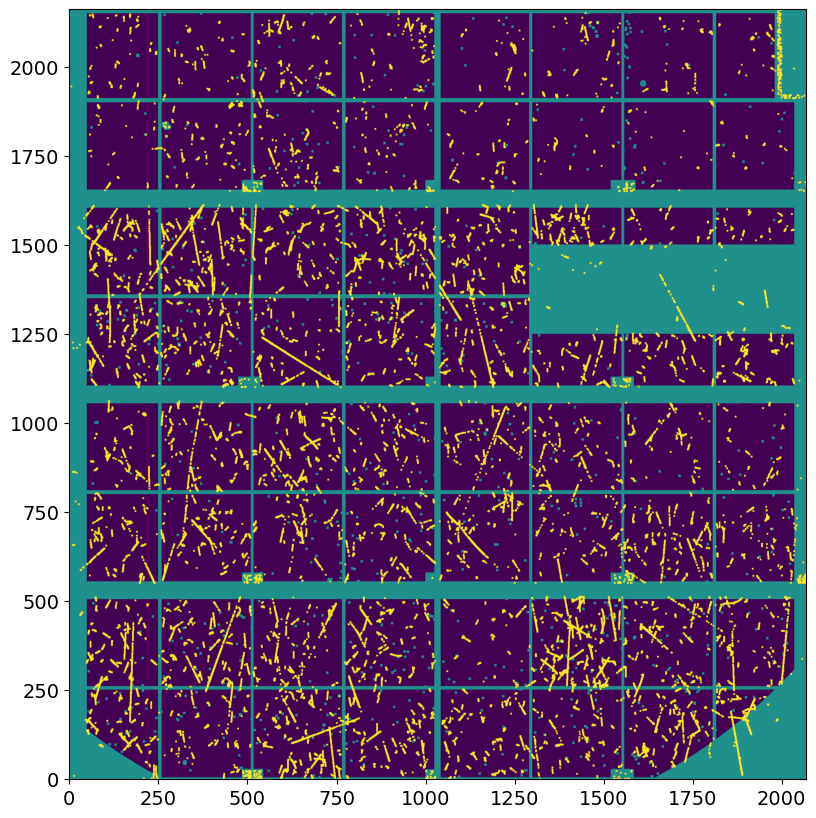

In [219]:
img = k[2][idxs].sum(axis=0).reshape(Nx,Ny)

img = binary_dilation(img, structure=np.ones((5,5)), iterations=1)

plt.figure(figsize=(10,10))
plt.imshow(img + .5*~mask.reshape(Nx,Ny), cmap='viridis', origin='lower', vmax=1)

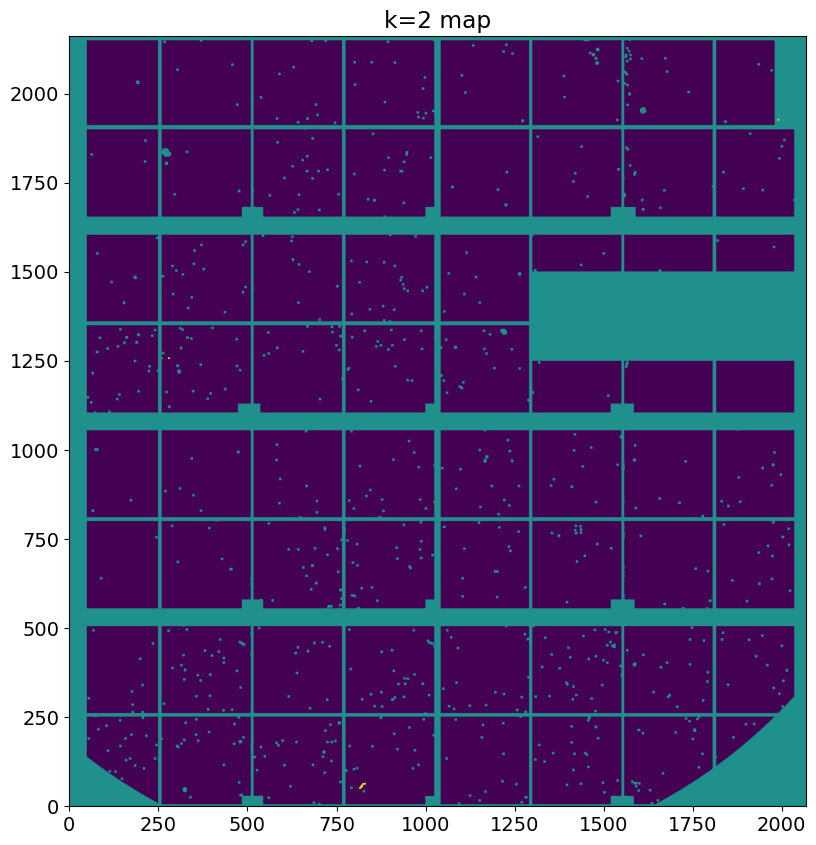

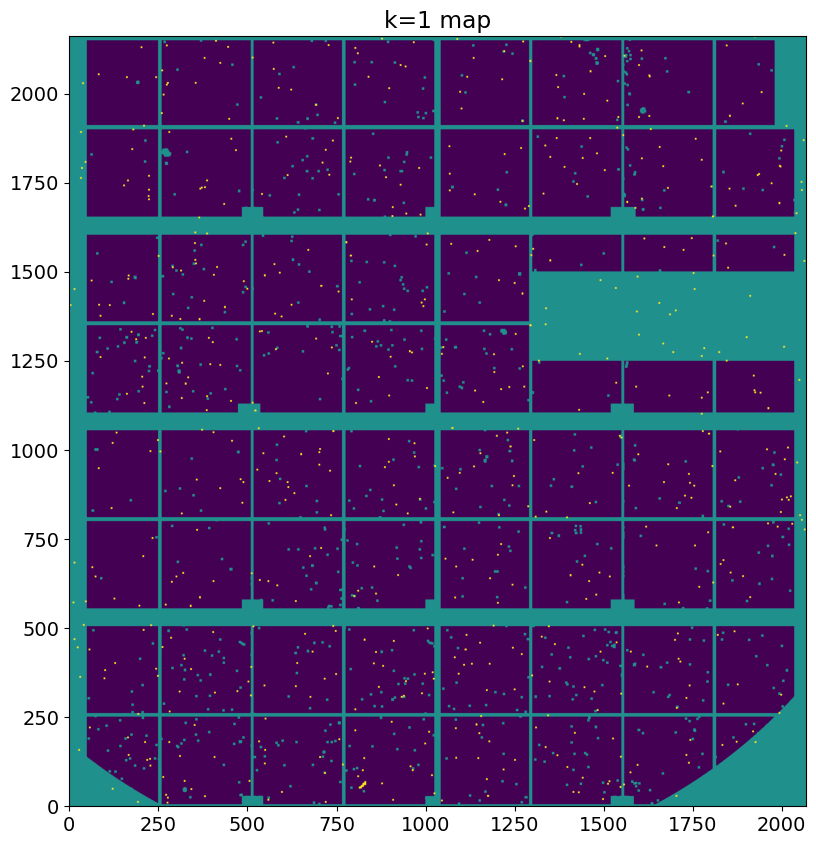

In [228]:
idx = idxs[1]

img = k[2][idx].reshape(Nx,Ny).toarray()
# dilatate img for plot
img = binary_dilation(img, structure=np.ones((5,5)), iterations=1)

plt.figure(figsize=(10,10))
plt.title('k=2 map')
plt.imshow(img + .5*~mask.reshape(Nx,Ny), cmap='viridis', origin='lower', vmax=1)

img = k[1][idx].reshape(Nx,Ny).toarray()
# dilatate img for plot
img = binary_dilation(img, structure=np.ones((5,5)), iterations=1)

plt.figure(figsize=(10,10))
plt.title('k=1 map')
plt.imshow(img + .5*~mask.reshape(Nx,Ny), cmap='viridis', origin='lower', vmax=1)

In [13]:
corr = e4m_data[1:]*e4m_data[:-1]

In [ ]:
k1 = e4m_data == 1
k2 = e4m_data == 2

k2.sum(axis=1)>6

NameError: name 'k2_filtered' is not defined

In [15]:
corrk1 = k1[1:]*k1[:-1]

In [ ]:
#e4m_data_bin = 

SyntaxError: invalid syntax (4109691048.py, line 1)

In [ ]:
k1_tsum = k1.sum(axis=0)
k2_tsum = k2.sum(axis=0)

In [ ]:
corr_tsum = corr.sum(axis=0)
corrk1_tsum = corrk1.sum(axis=0)

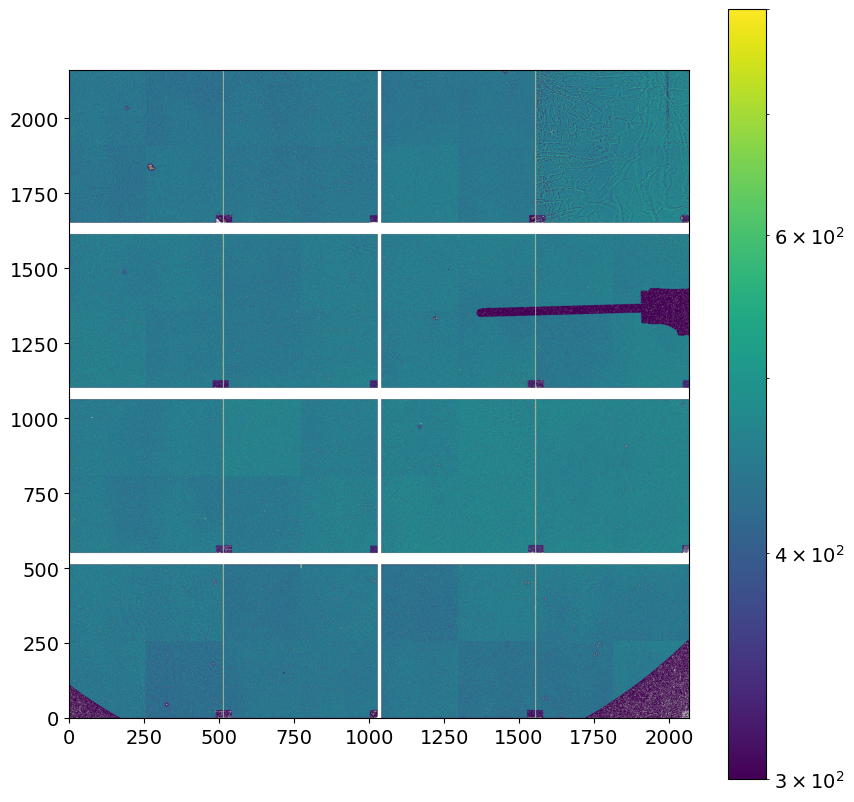

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(k1_tsum.reshape(Nx,Ny), origin='lower', vmin=300, vmax=800, norm='log')
plt.colorbar()

In [17]:
Dpx = 5
counts_th = 3

out = COSMIC.cosmic_filter(e4m_data, Dpx, counts_th)

Loading frames ...
Done! (elapsed time = 0.0 s)
	 | 1799288 frames X 4471016 pixels
	 | sparsity = 2.30e-04
	 | memory usage (sparse.csr_array @ float32) = 20.708 GB
Generating kernel matrix ...
Done! (elapsed time = 11.76 s)
Cosmic ray retrieval (using MKL library) ...


ValueError: mkl_sparse_spmm returned 2 (SPARSE_STATUS_ALLOC_FAILED);  Try changing MKL to int64 with the environment variable MKL_INTERFACE_LAYER=ILP64

In [ ]:
print(k2_tsum.sum())
print(corrk1_tsum.sum())

1603760
661443


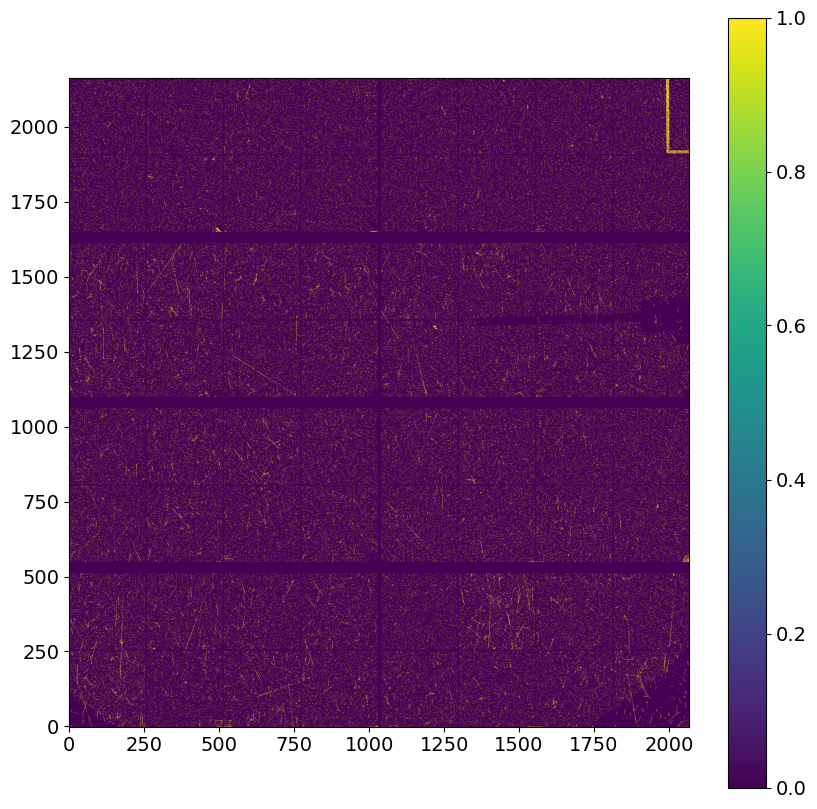

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(k2_tsum.reshape(Nx,Ny), origin='lower', vmax=1)
plt.colorbar()

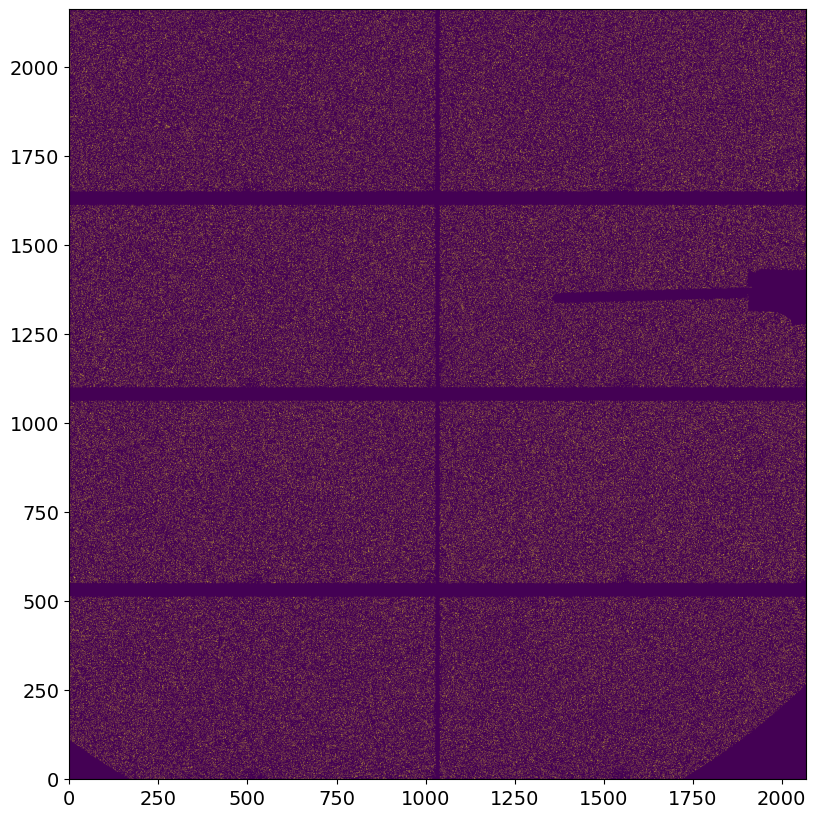

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow((corrk1_tmean>0).reshape(Nx,Ny), origin='lower')

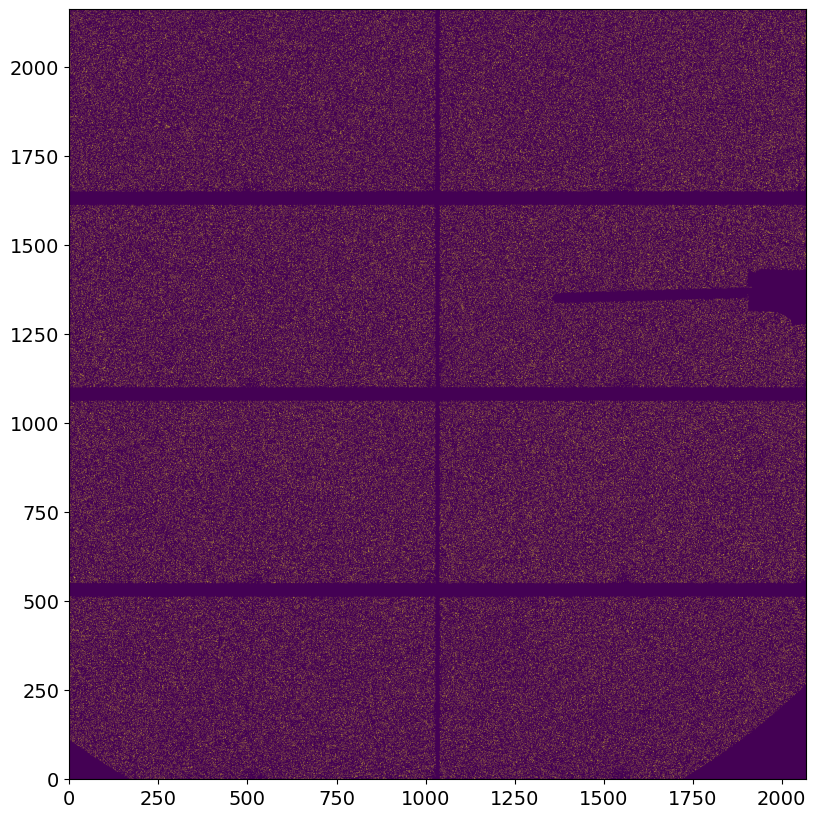

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow((corrk1_tmean>0).reshape(Nx,Ny), origin='lower')

## Tresh temp

### k distributions by frame

In [ ]:
k_t = {}
k_t_htmask = {}

k_t[1] = k[1].sum(axis=1)
k_t[2] = k[2].sum(axis=1)
k_t[3] = k[3].sum(axis=1)
k_t[4] = k[4].sum(axis=1)

k_t_htmask[1] = k[1].sum(axis=1)
k_t_htmask[2] = k[2][:,e4m_htmask].sum(axis=1)
k_t_htmask[3] = k[3][:,e4m_htmask].sum(axis=1)
k_t_htmask[4] = k[4][:,e4m_htmask].sum(axis=1)

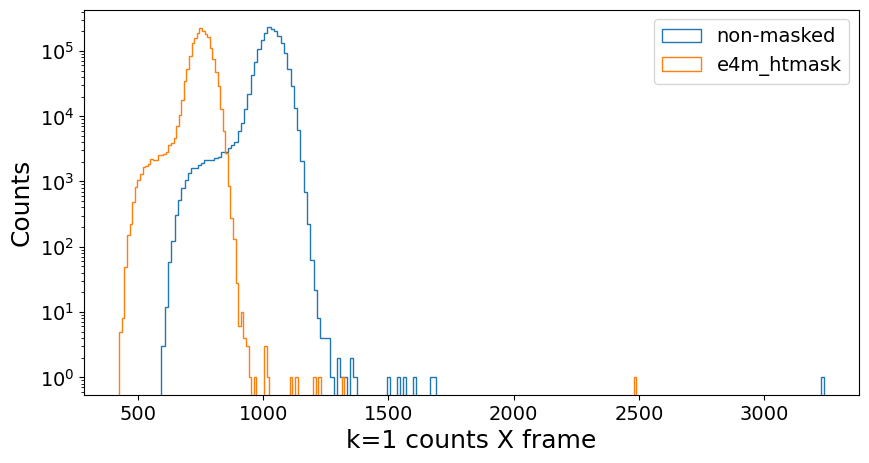

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(k_t[1],        bins=plt.figure(figsize=(10,10))
plt.imshow(k_p[2].reshape(Nx,Ny), cmap='magma_r', origin='lower', vmax=4)
plt.colorbar()200, histtype='step', label='non-masked')
plt.hist(k_t_htmask[1], bins=200, histtype='step', label='e4m_htmask')

plt.xlabel('k=1 counts X frame')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

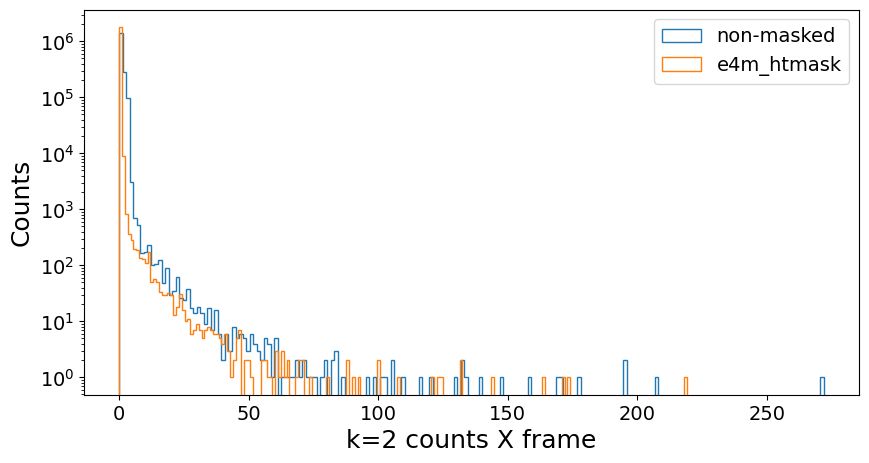

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(k_t[2],        bins=200, histtype='step', label='non-masked')
plt.hist(k_t_htmask[2], bins=200, histtype='step', label='e4m_htmask')

plt.xlabel('k=2 counts X frame')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

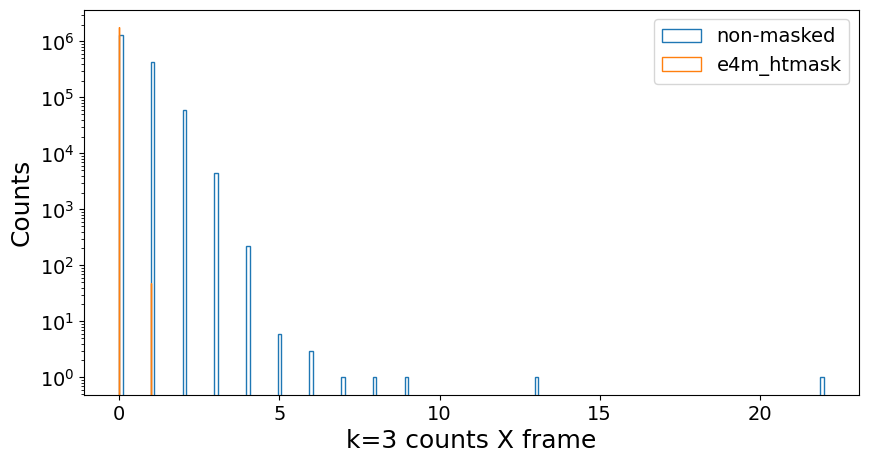

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(k_t[3],        bins=200, histtype='step', label='non-masked')
plt.hist(k_t_htmask[3], bins=200, histtype='step', label='e4m_htmask')

plt.xlabel('k=3 counts X frame')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

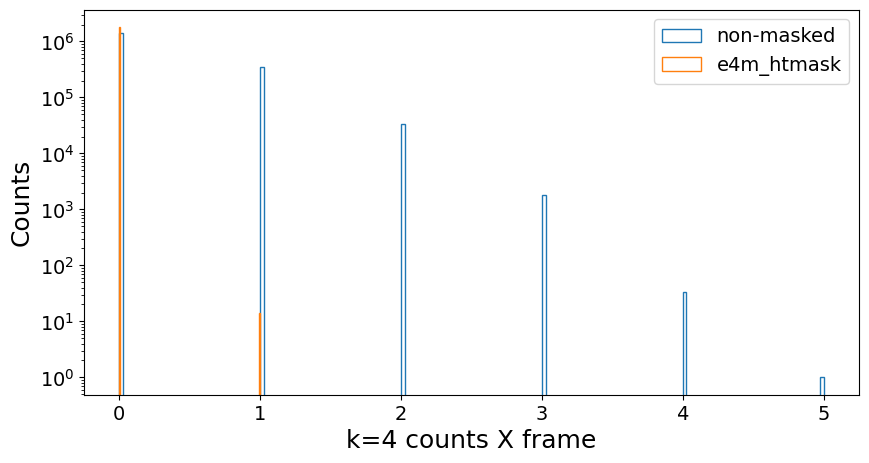

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(k_t[4],        bins=200, histtype='step', label='non-masked')
plt.hist(k_t_htmask[4], bins=200, histtype='step', label='e4m_htmask')

plt.xlabel('k=4 counts X frame')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()